<a href="https://colab.research.google.com/github/cosmicurvy/amazon-reviews-nlp/blob/main/notebooks/TopicModeling_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install gensim

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk # to preprocess text data
import re
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer # to convert text into numbers
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.decomposition import LatentDirichletAllocation # for topic modeling
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [4]:
dataset_path = '/content/drive/MyDrive/Sentiment-Classification/Musical_Instruments.jsonl.gz'
data = pd.read_json(dataset_path, lines=True, compression='gzip')

In [5]:
data.sample(3)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
2244141,5,Does what it is designed to do.,It is a very handy practice fret board intende...,[],B00CPPYPIQ,B00CPPYPIQ,AEFTIP5KILV62VRJF5W4AAULCUDQ,2018-12-24 03:54:38.602,1,False
851050,5,My favorite Behringer pedal,I own three Behringer pedals. All of them are...,[],B000T9PE9E,B000T9PE9E,AHVZ6QLCKN2KLBSU3JYVQENA7NMQ,2012-05-21 14:29:13.000,0,True
1589570,3,This Product has Some Issues.,Let me start off by stating that this could ea...,[],B004DYYPVO,B004DYYPVO,AGDQRSSZ4U3C3TXLIFOUYHO3A3LQ,2014-02-23 00:08:16.000,10,True


In [6]:
# extracting the required features
data = data[['title','text','rating']]

In [7]:
data.shape

(3017439, 3)

In [8]:
print("Total Duplicate Values: ", data.duplicated().sum())

Total Duplicate Values:  179889


In [9]:
# dropping the duplicate values
data = data.drop_duplicates()
data.shape

(2837550, 3)

- Due to the massive dataset size, a sample of 50,000 data points is used.

In [10]:
data = data.sample(50000, random_state = 35)
data.shape

(50000, 3)

In [11]:
sample_data_path = '/content/drive/MyDrive/Sentiment-Classification/'

# saving the  sample Dataset
data.to_csv(sample_data_path+'amazon_reviews.csv', index=False)

In [12]:
df = pd.read_csv("/content/drive/MyDrive/Sentiment-Classification/amazon_reviews.csv")
df.sample(5)

,title,text,rating
19833,Besutiful Ukelele Gig Bag!,"Beautiful, useful,<br />well-made Ukelele<br /...",5
22953,It has good quality for the price you pay,"When I first got it, I was a little bit iffy w...",5
42097,Print is nicely done,Everything was packaged nicely<br />Arrived fa...,5
26707,Great for the price,I was having problems with noise in a recordin...,5
26754,Two Stars,one of two stopped working within 3 months,2


In [13]:
df.shape

(50000, 3)

In [14]:
df.isna().sum()

,0
title,6
text,5
rating,0


In [15]:
df.dropna(inplace=True)

In [16]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
rating,49989.0,4.22619,1.295281,1.0,4.0,5.0,5.0,5.0


### EDA

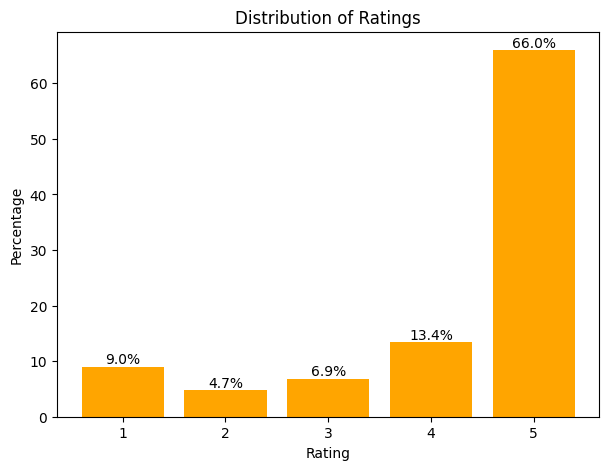

In [17]:
# visualizing the distribution of ratings
categories = df.rating.value_counts(normalize=True).index
percentages = df.rating.value_counts(normalize=True).values * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(categories, percentages, color='orange')
plt.bar_label(bars, fmt='%.1f%%')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Percentage")
plt.show()

- Most products received a 5‑star rating, indicating that the majority of reviews are positive. This shows a significant class imbalance in the data.

In [18]:
df['length'] = df['text'].apply(lambda x: len(x))

In [19]:
# function to get the sentiment for each review
def get_sentiment(rate):
  if rate in [1, 2]:
    return 'Negative'
  elif rate == 3:
    return "Neutral"
  else:
    return "Positive"

df['sentiment'] = df['rating'].apply(get_sentiment)

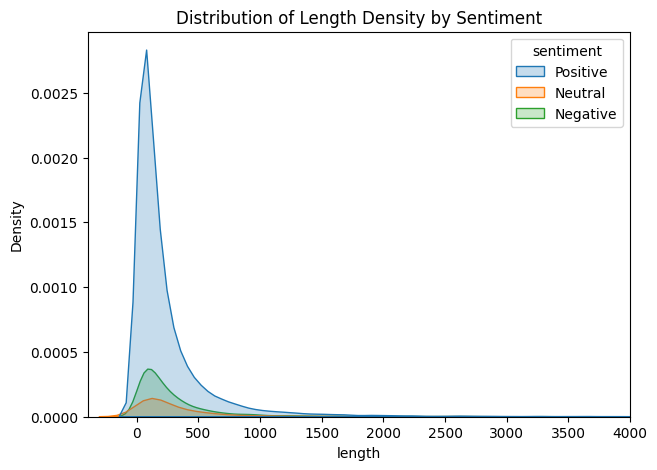

In [20]:
# visualizing the reviews length density per sentiment
plt.figure(figsize=(7,5))
sns.kdeplot(data=df, x= 'length', hue='sentiment', fill=True)

plt.title("Distribution of Length Density by Sentiment")
plt.xlim(-400, 4000)
plt.show()

### Text Preprocessing

- Before performing topic modeling, the reviews are preprocessed.


In [21]:
lemmatizer = WordNetLemmatizer()
stop_words = stopwords.words('english')

# function to clean the text
def preprocess_txt(text):
  text = text.lower()
  cleaned = re.sub(r'(<br\s*/?>)+', ' ', text)
  cleaned = re.sub(r'[^a-zA-Z0-9]', ' ', cleaned)
  tokens = word_tokenize(cleaned)
  cleaned_tokens = [lemmatizer.lemmatize(token) for token in tokens if not token in stop_words]
  cleaned_txt = ' '.join(cleaned_tokens)
  return cleaned_txt

df['preprocessed_text'] = df['text'].apply(lambda x: preprocess_txt(x))

In [22]:
df.head(3)

,title,text,rating,length,sentiment,preprocessed_text
0,BEST protection for many equipment needs!,I purchased the SKB mid-sized hardware case af...,5,777,Positive,purchased skb mid sized hardware case trying s...
1,Good value,"Well made, good fit & finish, does the job! I...",5,136,Positive,well made good fit finish job want spend money...
2,Nice for gaming,Sound quality is very good for gaming and onli...,5,56,Positive,sound quality good gaming online class


### Topic Modeling

- Topic Modeling is performed only on negative reviews to group different kinds of issues or complaints the users are facing.

In [23]:
# filteing the negative reviews
data_tm = df[df['sentiment'] == 'Negative']

In [24]:
data_tm.shape

(6874, 6)

In [25]:
# stop words for countvectorizer
overlapping_noise = ['product', 'work', 'worked', 'working', 'stopped', 'like', 'even', 'use', 'back', 'got', 'time',
                     'first', 'item', 'came', 'didnt', 'doesnt', 'one', 'get', 'would', 'really', 'much', 'using',
                     'way', 'good', 'great', 'bad', 'buy', 'bought', 'quality', '34']

- A Bag-of-Words (BoW) model using CountVectorizer is applied to convert unstructured text into numerical features.

- During topic modeling, significant word overlap between topics was observed, so these words were added to the stop_words parameter in CountVectorizer to reduce redundancy.

In [26]:
# initializing the vectorizer
vectorizer = CountVectorizer(stop_words= overlapping_noise, lowercase=False, max_df=0.75, min_df=5)
doc_matrix = vectorizer.fit_transform(data_tm['preprocessed_text']) # fit on negative reviwews
feature_names = vectorizer.get_feature_names_out()

In [27]:
#LDA
lda_model = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=15)
lda_model.fit(doc_matrix)

LatentDirichletAllocation(max_iter=15, n_components=5, random_state=42)

In [28]:
# extracting the top 15 words per topic
topics = []

for topic in lda_model.components_:
  top_words = [feature_names[i] for i in topic.argsort()[-15:][::-1]]
  topics.append(top_words)

In [29]:
analyzer = vectorizer.build_analyzer()

# this ensures gensim evaluates the exact same token scikit-learn processed
cleaned_tokens = [analyzer(doc) for doc in data_tm['preprocessed_text']]

In [30]:
# creating a dictionary
gensim_dict = Dictionary(cleaned_tokens)

- Coherence score is used to evaluate the LDA topics, it measures how clear (semantically meaningful) the topics are.

In [31]:
# initializing the coherence model
coherence_model = CoherenceModel(topics= topics, texts = cleaned_tokens, dictionary= gensim_dict,  coherence='c_v')

print("Coherence Score: ", coherence_model.get_coherence())

Coherence Score:  0.5433963485253714


In [32]:
for topic in topics:
  print(topic)

['return', 'month', 'day', 'broke', 'amazon', 'week', 'year', 'received', 'never', 'new', 'light', 'used', 'replacement', 'two', 'customer']
['cable', 'pedal', 'power', 'device', 'bag', 'usb', 'plug', 'also', 'thing', 'mic', 'headphone', 'need', 'keyboard', 'sound', 'used']
['guitar', 'string', 'play', 'instrument', 'sound', 'tune', 'playing', 'tuner', 'neck', 'made', 'look', 'better', 'well', 'strap', 'pick']
['sound', 'mic', 'speaker', 'amp', 'noise', 'volume', 'money', 'microphone', 'better', 'make', 'audio', 'unit', 'loud', 'something', 'hear']
['stand', 'fit', 'cheap', 'plastic', 'hold', 'screw', 'part', 'piece', 'mic', 'made', 'arm', 'metal', 'look', 'hole', 'small']


In [33]:
topic0 = "return, month, day, broke, amazon, week, year, received, never, new, light, used, replacement, two, customer"
topic1 = "cable, pedal, power, device, bag, usb, plug, also, thing, mic, headphone, need, keyboard, sound, used"
topic2 = "guitar, string, play, instrument, sound, tune, playing, tuner, neck, made, look, better, well, strap, pick"
topic3 = "sound, mic, speaker, amp, noise, volume, money, microphone, better, make, audio, unit, loud, something, hear"
topic4 = "stand, fit, cheap, plastic, hold, screw, part, piece, mic, made, arm, metal, look, hole, small"

In [34]:
# function for  word cloud
def generate_wordcloud(words, topic, ax):
  wc = WordCloud(width=1000,height=700, background_color='black').generate(words)
  ax.set_title(f"{topic}")
  ax.imshow(wc)
  ax.axis('off')

### WordCloud

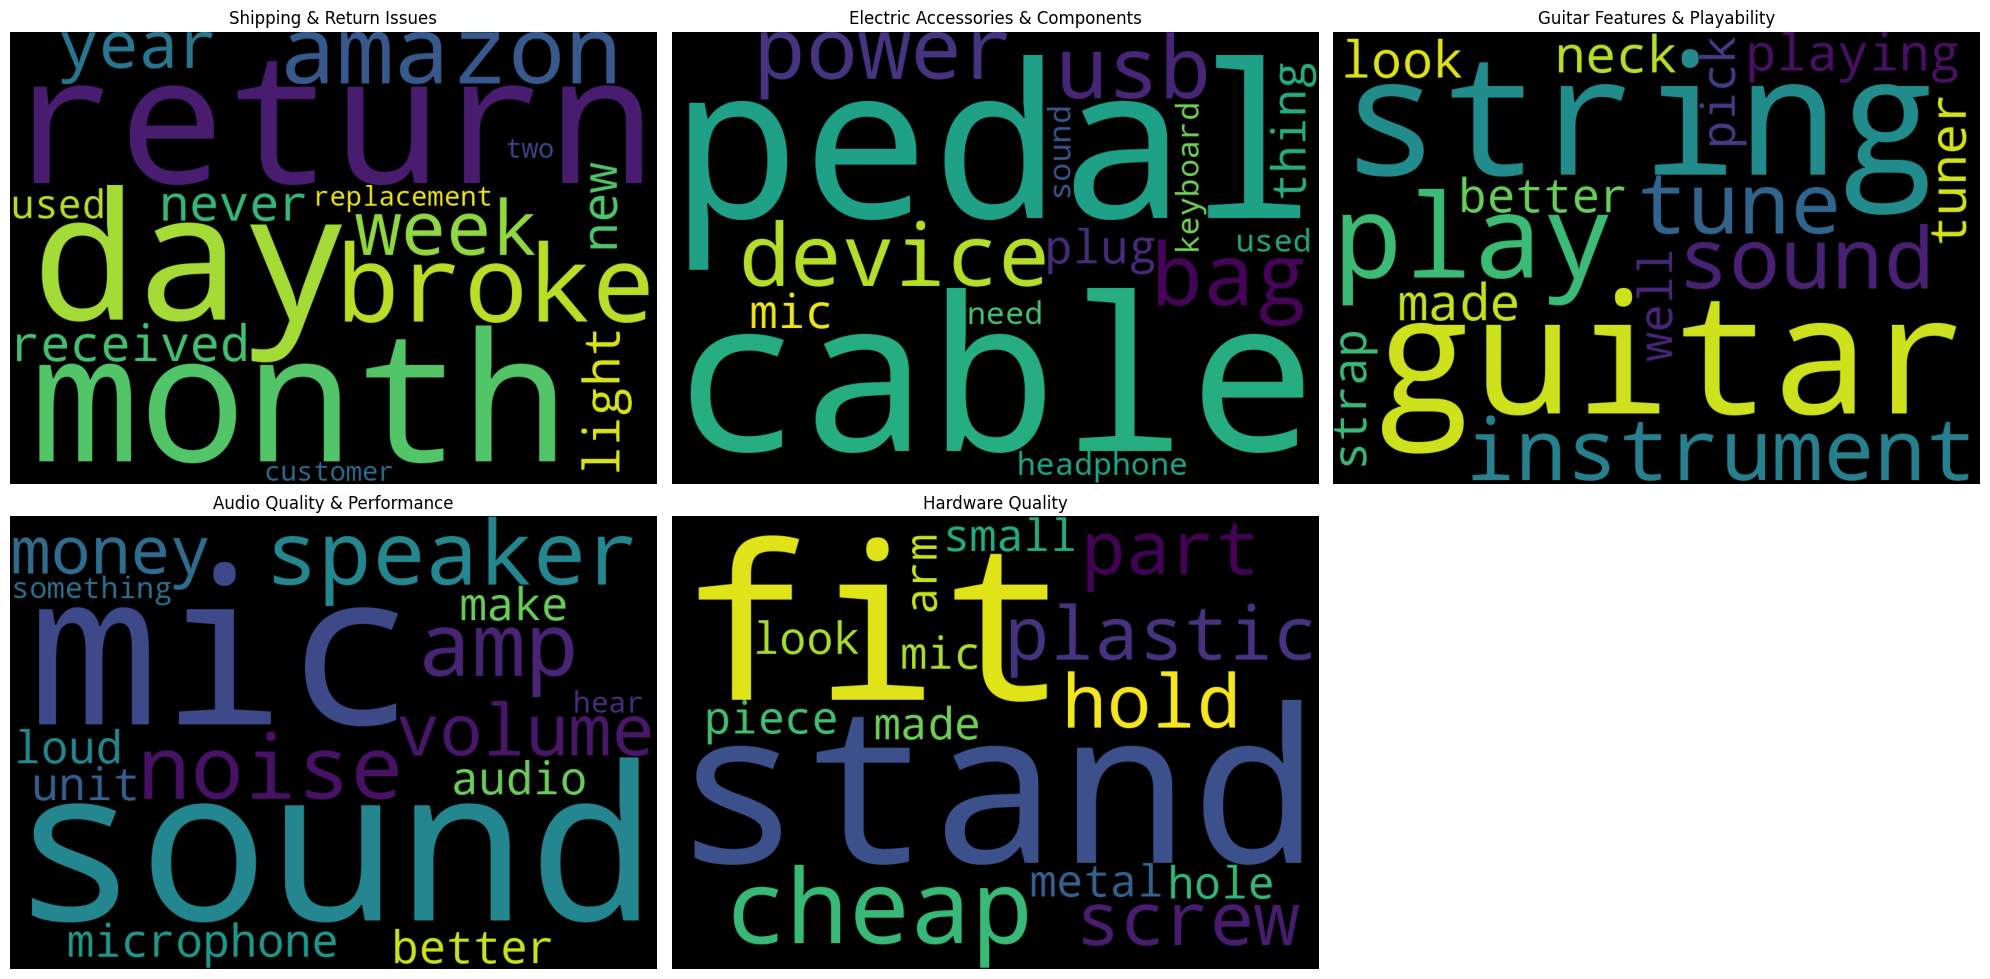

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(20,10))
axes = axes.flatten()

generate_wordcloud(words= topic0, topic="Shipping & Return Issues", ax= axes[0])
generate_wordcloud(words= topic1, topic="Electric Accessories & Components", ax= axes[1])
generate_wordcloud(words= topic2, topic="Guitar Features & Playability", ax= axes[2])
generate_wordcloud(words= topic3, topic="Audio Quality & Performance", ax= axes[3])
generate_wordcloud(words= topic4, topic="Hardware Quality", ax= axes[4])

axes[5].set_visible(False)

plt.tight_layout()
plt.show()

In [36]:
# topic probabilities
topic_probabilities = lda_model.transform(doc_matrix)
topic_names = {0: 'Shipping & Return Issues', 1: 'Electric Accessories & Components', 2: 'Guitar Features & Playability', 3: 'Audio Quality & Performance', 4: 'Hardware Quality'}

# creating new columns
data_tm['topic'] = topic_probabilities.argmax(axis=1)
data_tm['topic_probs'] = topic_probabilities.max(axis=1)
data_tm['topic_name'] = data_tm['topic'].map(topic_names)

In [37]:
data_tm.sample(3)

,title,text,rating,length,sentiment,preprocessed_text,topic,topic_probs,topic_name
23738,"As soon as I tried to tune it, one ...","As soon as I tried to tune it, one of the E st...",1,676,Negative,soon tried tune one e string broke know happen...,2,0.906158,Guitar Features & Playability
47670,"ABHORRENT tone, crap quality for a ""boutique"" ...",Extremely disappointed with this pedal. Wample...,1,888,Negative,extremely disappointed pedal wampler serious g...,3,0.569052,Audio Quality & Performance
25198,Quite lame,I love all things Apple. But this software is...,2,138,Negative,love thing apple software lame nothing garageb...,3,0.926351,Audio Quality & Performance


In [38]:
# extracting top 5 reviews for each topic
top_reviews = pd.DataFrame()

for topic_id in topic_names.keys():
  top_5 = data_tm[data_tm['topic']== topic_id].sort_values(by='topic_probs', ascending=False).head(5)
  top_reviews = pd.concat([top_reviews, top_5])

- To make the model results easier to interpret, the original raw review text is dispalyed for each topic rather than the preprocessed text.

In [39]:
print("Top 5 Reviews of Topic 0 (Shipping & Return Issues) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[:5, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 0 (Shipping & Return Issues) -->


1) I successfully installed this program, but to run it you need to "activate" it - enter your name, the serial number, your email address and ...
2) we purchased this machine to use as special effects with photography. We tested it out when it was first received and it worked fine.  Clean...
3) I will update my review to say that it has now been three weeks since I contacted 1byone's customer service and I still have not heard from ...
4) I originally purchased this item 2 day air.  After 7 days I contacted Amazon and they basically told me that that happens some times.  They ...
5) I like this light a lot, but it needs constant recharging.  I've had it for a while, and a full charge (based on the light display on the un...


In [40]:
print("Top 5 Reviews of Topic 1 (Electric Accessories & Components) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[5:10, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 1 (Electric Accessories & Components) -->


1) I bought this to act as footswitch 4 and footswitch 5 on my HX Stomp like a few other people have done. I have tried with three different TR...
2) The chip was sent inside an anti-static bag.  No instructions or paperwork of any kind was included.  No markings on the chip at all...not t...
3) The picture of this product shows SILVER charms but I received GOLD charms... as it seems others did in looking at these videos posted.  ???...
4) The USB port on the back of the mic that I received is NOT the type shown in the picture. THIS IS IMPORTANT, PEOPLE. I ordered this along wi...
5) When I plug the controller into my computer, with or without DJUCED software open, my pc says "USB device malfunctioned and is not recognize...


In [41]:
print("Top 5 Reviews of Topic 2 (Guitar Features & Playability) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[10:15, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 2 (Guitar Features & Playability) -->


1) Update 8/17/2021:  at first this ukulele was not bad after doing a set up. As time went on the neck began to bow… and bow… and bow.  There w...
2) Absolutely beautiful finish but chromatically way out of tune to the point I could not even play it. It literally hurt my ears.<br />Turns o...
3) I'm a guitar builder, guitarist, bassist, and ukelele player.  I also teach guitar to children and adults.<br /><br />I was really disappoin...
4) In short, it's too small. I have two guitars - a Squier Strat and an Epiphone SG400. I measured them both from the rear strap button to the ...
5) I was skeptical about some of the reviews for this guitar. Issues with tuning and string tension are quite normal for new guitars (incl. exp...


In [42]:
print("Top 5 Reviews of Topic 3 (Audio Quality & Performance) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[15:20, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 3 (Audio Quality & Performance) -->


1) The Hartke LH500 was severely lacking in the power output and tone quality that I was expecting for the price, especially in the lower regis...
2) My recommendation to you, is before purchasing this product, or a product like it, try it before you buy it 100% of the time.  Take your tim...
3) When I installed this amplifier, I ran it with a 10” JL Audio W0 at 4 ohms.  It sounded great for all of 5 minutes before the safety tripped...
4) Well for starters, this mic was a decent microphone. It will never compare to a top quality condenser microphone, but it has its place. The ...
5) Initially this microphone worked fine I’ll give it having some problems with sound quality .it was a tad too quiet. I had to turn the output...


In [43]:
print("Top 5 Reviews of Topic 4 (Hardware Quality) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[20:, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 4 (Hardware Quality) -->


1) Mount is much smaller than I expected. The mount I got does not look like the on in the picture. What I revived is not at all what was descr...
2) I bought the 1 1/2&#34; bells, they were pretty, well proportioned but a little small. I kept them and braided them into a cord and thought ...
3) Mine failed in 2 ways:<br /><br />The first problem - the bottom of the main Center Column is merely crimped against the Threaded Bolt that ...
4) To be honest.  it was cracked on the top screw in that holds the mic bar to the stand, when I bought it.  You spend cheap, you get cheap and...
5) What gives?  I have a Shure SM58 microphone so I bought this Shure A25D holder that clearly states it is for a Shure SM58.  But the micropho...


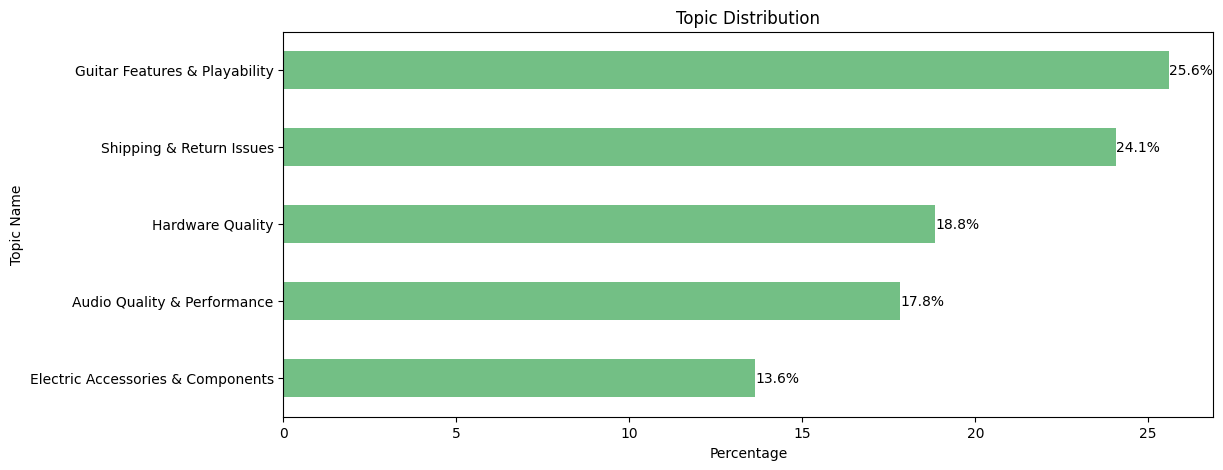

In [44]:
# visualizing the topic distribution
plt.figure(figsize= (12,5))

ax = (data_tm['topic_name'].value_counts(normalize=True) * 100).sort_values().plot(kind='barh', color='#73bf85')
for container in ax.containers:
  ax.bar_label(container, fmt='%.1f%%')

plt.title("Topic Distribution")
plt.xlabel('Percentage')
plt.ylabel("Topic Name")
plt.show()

- Most of the reviews fall under the `Guitar Features & Playability` (Topic 2), followed by `Shipping & Return Issues` (Topic 0) and `Hardware Quality` (Topic 4).

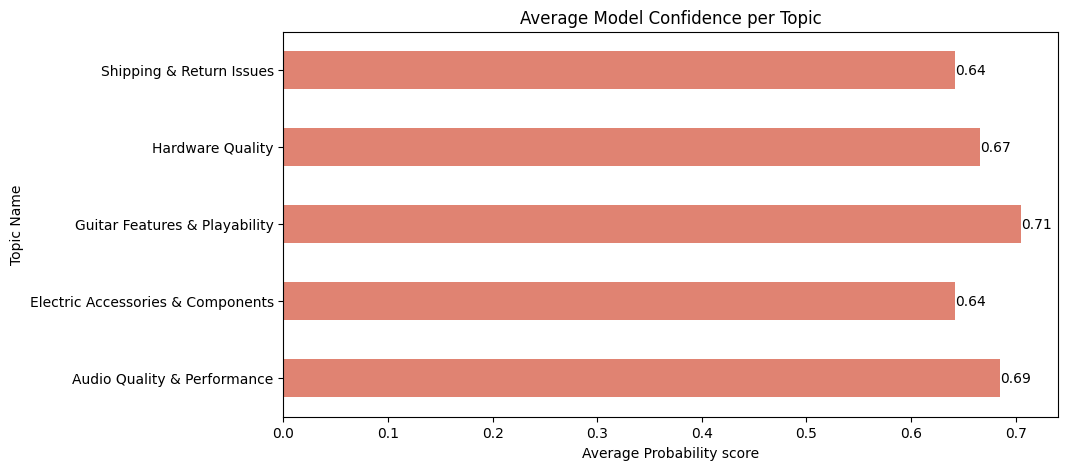

In [45]:
# visualizing the average model confidence
plt.figure(figsize= (10,5))
ax = data_tm.groupby('topic_name')['topic_probs'].mean().plot(kind='barh', color='#e08372')

for container in ax.containers:
  ax.bar_label(container, fmt= '%.2f')

plt.title("Average Model Confidence per Topic")
plt.xlabel('Average Probability score')
plt.ylabel("Topic Name")
plt.show()

- Average probability score is higher for `Guitar Features & Playability` topic, followed by `Audio Quality & Performance` topic and `Hardware Quality` topic.